# Phase 4 — YOLOv8-seg + Depth + MLP Regression Pipeline

**Goal**: Implement the full proposal pipeline to replace / extend the Phase 3 baseline.

| Step | Description |
|------|-------------|
| 1 | Install dependencies & setup |
| 2 | Auto-detect dataset paths |
| 3 | YOLOv8-seg → food region masks |
| 4 | Depth feature extraction (real depth images + MiDaS fallback) |
| 5 | Feature engineering |
| 6 | MLP regression head training |
| 7 | Uncertainty estimation (MC Dropout) |
| 8 | Evaluation & comparison with Phase 3 baseline |
| 9 | Save pipeline artifacts |
| 10 | Phase 4 summary |

**Novelties over Phase 3:**
- Multi-stage: detect → segment → depth → regress
- Geometric reasoning (mask area + depth cues) instead of pure RGB
- Uncertainty-aware predictions (MC Dropout ±bounds)

In [1]:
# ── Step 1: Install dependencies ──────────────────────────────────────────────
# Run this cell once. On Kaggle: Accelerator = GPU T4, Internet = ON
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('ultralytics')   # YOLOv8
pip_install('timm')          # MiDaS backbone weights

print('✓ ultralytics and timm installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.9 MB/s eta 0:00:00
✓ ultralytics and timm installed


In [2]:
# ── Imports & reproducibility ─────────────────────────────────────────────────
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ultralytics import YOLO

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print(f'✓ Device: {device}')
if device.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Device: cuda
  GPU : Tesla T4


In [3]:
# ── Step 2: Auto-detect dataset paths ─────────────────────────────────────────
KAGGLE_ROOT = '/kaggle/input'
LOCAL_DATA  = '../data'

nutrition_csv = img_dir = None
search_root = KAGGLE_ROOT if os.path.isdir(KAGGLE_ROOT) else LOCAL_DATA

for root, dirs, files in os.walk(search_root):
    for f in files:
        if f == 'dish_nutrition_values.csv':
            nutrition_csv = os.path.join(root, f); break
    if nutrition_csv: break

for root, dirs, files in os.walk(search_root):
    if len([d for d in dirs if d.startswith('dish_')]) > 10:
        img_dir = root; break

assert nutrition_csv and os.path.isfile(nutrition_csv), 'CSV not found!'
assert img_dir and os.path.isdir(img_dir), 'Image dir not found!'
print(f'CSV      : {nutrition_csv}')
print(f'Image dir: {img_dir}')

# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(nutrition_csv)
dish_id_col = df.columns[0]

def find_col(df, kws):
    for kw in kws:
        m = next((c for c in df.columns if kw in c.lower()), None)
        if m: return m

TARGET_COLS = [c for c in [
    find_col(df, ['calor']), find_col(df, ['fat']),
    find_col(df, ['protein']), find_col(df, ['carb'])
] if c]
NUM_TARGETS = len(TARGET_COLS)

available = set(os.listdir(img_dir))
def has_images(did):
    p = os.path.join(img_dir, did)
    return os.path.isdir(p) and any(f.lower().endswith(('.jpg','.png')) for f in os.listdir(p))

df_valid = df[df[dish_id_col].isin(available)].reset_index(drop=True)
df_valid = df_valid[df_valid[dish_id_col].apply(has_images)].reset_index(drop=True)
print(f'Valid dishes : {len(df_valid)}')
print(f'Target cols  : {TARGET_COLS}')

CSV      : /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
Image dir: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead
Valid dishes : 3247
Target cols  : ['calories', 'fat', 'protein', 'carb']


In [4]:
# ── Step 3: Load YOLOv8-seg model ─────────────────────────────────────────────
#
# We use YOLOv8n-seg (nano, fastest). It is pretrained on COCO-seg.
# We run it on each dish image to extract a food-region mask.
# Classes like 'bowl', 'cup', 'sandwich', 'pizza', 'cake', 'donut',
# 'broccoli', 'carrot', 'hot dog', 'fork', 'knife', 'spoon' are
# all useful for identifying the food region on a plate.
#
# If no COCO food class is detected we fall back to the centre crop.

FOOD_CLASSES = {
    # COCO class IDs that correspond to food or tableware
    # (see https://docs.ultralytics.com/datasets/detect/coco/)
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon',
    45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange',
    50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza',
    54: 'donut', 55: 'cake',
    60: 'dining table',
}

try:
    yolo = YOLO('yolov8n-seg.pt')   # downloads ~6 MB
    print('✓ YOLOv8n-seg loaded')
except Exception as e:
    print(f'⚠ YOLO load failed: {e}')
    yolo = None


def get_food_mask(img_path: str, img_size: int = 224) -> np.ndarray:
    """
    Returns a binary mask (H, W) float32 in [0,1] for the food region.
    Falls back to a centre-crop circle if YOLO finds nothing.
    """
    img = cv2.imread(img_path)
    if img is None:
        img = np.array(Image.open(img_path).convert('RGB'))[:, :, ::-1]
    H, W = img.shape[:2]
    fallback = _centre_mask(H, W)

    if yolo is None:
        return cv2.resize(fallback, (img_size, img_size)).astype(np.float32)

    results = yolo(img, verbose=False)[0]

    if results.masks is None or len(results.masks) == 0:
        return cv2.resize(fallback, (img_size, img_size)).astype(np.float32)

    # Combine all food-class masks (or all masks if none match food classes)
    classes = results.boxes.cls.cpu().numpy().astype(int)
    food_idx = [i for i, c in enumerate(classes) if c in FOOD_CLASSES]
    if not food_idx:
        food_idx = list(range(len(classes)))  # use all detections

    combined = np.zeros((H, W), dtype=np.float32)
    for i in food_idx:
        m = results.masks[i].data[0].cpu().numpy()   # (H', W') in [0,1]
        m_resized = cv2.resize(m, (W, H))
        combined = np.maximum(combined, m_resized)

    combined = (combined > 0.5).astype(np.float32)
    if combined.sum() < 100:           # too small — fall back
        combined = fallback
    return cv2.resize(combined, (img_size, img_size)).astype(np.float32)


def _centre_mask(H, W, ratio=0.6):
    """Circular centre mask as fallback."""
    mask = np.zeros((H, W), dtype=np.float32)
    cy, cx = H // 2, W // 2
    r = int(min(H, W) * ratio / 2)
    cv2.circle(mask, (cx, cy), r, 1.0, -1)
    return mask


print('✓ get_food_mask() defined')

✓ YOLOv8n-seg loaded
✓ get_food_mask() defined


In [5]:
# ── Step 4: Depth feature extraction ──────────────────────────────────────────
#
# Nutrition5K dishes were captured with an Intel RealSense depth camera.
# Each dish folder contains a 'depth_color.png' (or similar) depth image.
# We try to load the real depth first; if absent, we fall back to MiDaS.

DEPTH_FILENAMES = ['depth_color.png', 'depth.png', 'depth_raw.png',
                   'side_depth_color.png']

# ── Lazy-load MiDaS (only if needed) ─────────────────────────────────────────
_midas_model = None
_midas_transform = None

def _load_midas():
    global _midas_model, _midas_transform
    if _midas_model is not None:
        return
    print('Loading MiDaS (first use)...')
    _midas_model = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small',
                                   trust_repo=True)
    _midas_model.to(device).eval()
    transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    _midas_transform = transforms.small_transform
    print('✓ MiDaS loaded')


def get_depth_map(dish_path: str, img_path: str, size: int = 224) -> np.ndarray:
    """
    Returns a (size, size) float32 depth map normalised to [0, 1].
    Tries real depth image first, then MiDaS.
    """
    # 1. Try real depth image from the dataset
    for fname in DEPTH_FILENAMES:
        dp = os.path.join(dish_path, fname)
        if os.path.isfile(dp):
            d = cv2.imread(dp, cv2.IMREAD_UNCHANGED)
            if d is not None:
                if len(d.shape) == 3:
                    d = cv2.cvtColor(d, cv2.COLOR_BGR2GRAY)
                d = d.astype(np.float32)
                dmax = d.max()
                if dmax > 0: d /= dmax
                return cv2.resize(d, (size, size))

    # 2. Fallback: MiDaS on RGB image
    try:
        _load_midas()
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            img_bgr = cv2.cvtColor(np.array(Image.open(img_path).convert('RGB')),
                                   cv2.COLOR_RGB2BGR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        inp = _midas_transform(img_rgb).to(device)
        with torch.no_grad():
            pred = _midas_model(inp).squeeze().cpu().numpy()
        pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
        return cv2.resize(pred, (size, size))
    except Exception as e:
        # Last resort: uniform depth
        return np.full((size, size), 0.5, dtype=np.float32)


print('✓ get_depth_map() defined')

✓ get_depth_map() defined


In [6]:
# ── Step 5: Feature engineering ───────────────────────────────────────────────
#
# For each dish we extract a compact feature vector:
#   [mask_area_ratio,
#    depth_mean, depth_std, depth_median, depth_max,    <- whole image
#    masked_depth_mean, masked_depth_std, masked_depth_median,  <- inside mask
#    masked_depth_max]
# Total: 9 features
#
# This is intentionally small so the MLP trains quickly even on CPU.

IMG_SIZE   = 224
FEAT_SIZE  = 9
CACHE_PATH = 'features_cache.npz'  # saved so we don't recompute


def extract_features(dish_id: str) -> np.ndarray:
    dish_path = os.path.join(img_dir, dish_id)
    imgs = sorted([f for f in os.listdir(dish_path)
                   if f.lower().endswith(('.jpg', '.png'))
                   and 'depth' not in f.lower()])
    if not imgs:
        return np.zeros(FEAT_SIZE, dtype=np.float32)

    img_path = os.path.join(dish_path, imgs[0])

    mask  = get_food_mask(img_path, IMG_SIZE)          # (224,224) in {0,1}
    depth = get_depth_map(dish_path, img_path, IMG_SIZE)  # (224,224) in [0,1]

    mask_area = mask.mean()                             # fraction of image covered

    d_mean   = depth.mean()
    d_std    = depth.std()
    d_med    = float(np.median(depth))
    d_max    = depth.max()

    masked = depth[mask > 0.5]
    if len(masked) == 0:
        masked = depth.flatten()

    md_mean = masked.mean()
    md_std  = masked.std()
    md_med  = float(np.median(masked))
    md_max  = masked.max()

    return np.array([mask_area,
                     d_mean, d_std, d_med, d_max,
                     md_mean, md_std, md_med, md_max],
                    dtype=np.float32)


print('✓ extract_features() defined')
print(f'  Feature vector size: {FEAT_SIZE}')
print(f'  Features: mask_area | depth stats (4) | masked-depth stats (4)')

✓ extract_features() defined
  Feature vector size: 9
  Features: mask_area | depth stats (4) | masked-depth stats (4)


In [7]:
# ── Build / load feature cache ─────────────────────────────────────────────────
# This step takes a while (runs YOLO + depth per dish).
# Results are cached to disk so you can re-run later without recomputing.

dish_ids = df_valid[dish_id_col].tolist()
targets  = df_valid[TARGET_COLS].values.astype(np.float32)  # (N, 4)

if os.path.isfile(CACHE_PATH):
    print(f'Loading cached features from {CACHE_PATH} ...')
    cached   = np.load(CACHE_PATH)
    features = cached['features']   # (N, FEAT_SIZE)
    print(f'✓ Loaded {len(features)} cached feature vectors')
else:
    print(f'Extracting features for {len(dish_ids)} dishes ...')
    print('  (This may take 10-30 min on CPU; ~2-5 min on GPU T4)')
    features = np.zeros((len(dish_ids), FEAT_SIZE), dtype=np.float32)
    t0 = time.time()
    for i, did in enumerate(dish_ids):
        features[i] = extract_features(did)
        if (i + 1) % 100 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(dish_ids) - i - 1)
            print(f'  {i+1}/{len(dish_ids)} done  '
                  f'({elapsed/60:.1f} min elapsed, ~{eta/60:.1f} min remaining)')
    np.savez(CACHE_PATH, features=features)
    print(f'✓ Features saved to {CACHE_PATH}')

print(f'Feature matrix: {features.shape}  Target matrix: {targets.shape}')

Extracting features for 3247 dishes ...
  (This may take 10-30 min on CPU; ~2-5 min on GPU T4)
  100/3247 done  (0.2 min elapsed, ~5.2 min remaining)
  200/3247 done  (0.3 min elapsed, ~4.9 min remaining)
  300/3247 done  (0.5 min elapsed, ~4.5 min remaining)
  400/3247 done  (0.6 min elapsed, ~4.2 min remaining)
  500/3247 done  (0.7 min elapsed, ~4.0 min remaining)
  600/3247 done  (0.9 min elapsed, ~3.8 min remaining)
  700/3247 done  (1.0 min elapsed, ~3.6 min remaining)
  800/3247 done  (1.1 min elapsed, ~3.5 min remaining)
  900/3247 done  (1.3 min elapsed, ~3.3 min remaining)
  1000/3247 done  (1.4 min elapsed, ~3.2 min remaining)
  1100/3247 done  (1.5 min elapsed, ~3.0 min remaining)
  1200/3247 done  (1.7 min elapsed, ~2.9 min remaining)
  1300/3247 done  (1.9 min elapsed, ~2.8 min remaining)
  1400/3247 done  (2.0 min elapsed, ~2.7 min remaining)
  1500/3247 done  (2.1 min elapsed, ~2.5 min remaining)
  1600/3247 done  (2.3 min elapsed, ~2.4 min remaining)
  1700/3247 done  

100%|██████████| 81.8M/81.8M [00:00<00:00, 201MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


✓ MiDaS loaded
  1900/3247 done  (2.9 min elapsed, ~2.0 min remaining)
  2000/3247 done  (3.0 min elapsed, ~1.9 min remaining)
  2100/3247 done  (3.2 min elapsed, ~1.7 min remaining)
  2200/3247 done  (3.3 min elapsed, ~1.6 min remaining)
  2300/3247 done  (3.4 min elapsed, ~1.4 min remaining)
  2400/3247 done  (3.6 min elapsed, ~1.3 min remaining)
  2500/3247 done  (3.7 min elapsed, ~1.1 min remaining)
  2600/3247 done  (3.9 min elapsed, ~1.0 min remaining)
  2700/3247 done  (4.0 min elapsed, ~0.8 min remaining)
  2800/3247 done  (4.2 min elapsed, ~0.7 min remaining)
  2900/3247 done  (4.3 min elapsed, ~0.5 min remaining)
  3000/3247 done  (4.5 min elapsed, ~0.4 min remaining)
  3100/3247 done  (4.6 min elapsed, ~0.2 min remaining)
  3200/3247 done  (4.7 min elapsed, ~0.1 min remaining)
✓ Features saved to features_cache.npz
Feature matrix: (3247, 9)  Target matrix: (3247, 4)


In [8]:
# ── Step 6: MLP regression head ───────────────────────────────────────────────

# ── 80/10/10 split (same seed as Phase 3 for fair comparison) ────────────────
torch.manual_seed(SEED)
n       = len(df_valid)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
indices = torch.randperm(n).tolist()
tr_idx  = indices[:n_train]
va_idx  = indices[n_train:n_train + n_val]
te_idx  = indices[n_train + n_val:]

X_train, y_train = features[tr_idx], targets[tr_idx]
X_val,   y_val   = features[va_idx], targets[va_idx]
X_test,  y_test  = features[te_idx], targets[te_idx]

# ── Normalise features ────────────────────────────────────────────────────────
feat_mean = X_train.mean(0, keepdims=True)
feat_std  = X_train.std(0, keepdims=True) + 1e-8
X_train_n = (X_train - feat_mean) / feat_std
X_val_n   = (X_val   - feat_mean) / feat_std
X_test_n  = (X_test  - feat_mean) / feat_std


class FeatDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_loader = DataLoader(FeatDataset(X_train_n, y_train), batch_size=64, shuffle=True)
va_loader = DataLoader(FeatDataset(X_val_n,   y_val),   batch_size=64)
te_loader = DataLoader(FeatDataset(X_test_n,  y_test),  batch_size=64)

print(f'Train: {len(tr_idx)}  Val: {len(va_idx)}  Test: {len(te_idx)}')

Train: 2597  Val: 324  Test: 326


In [9]:
# ── MLP definition ────────────────────────────────────────────────────────────
#
# Input  : 9 geometric features
# Hidden : 128 → 64 → 32 with BN + ReLU + Dropout
# Output : NUM_TARGETS (4)
#
# Dropout(0.2) is kept at inference for MC Dropout uncertainty.

class NutritionMLP(nn.Module):
    def __init__(self, in_feats: int, num_targets: int, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_feats, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),       nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64,  32),       nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, num_targets),
        )

    def forward(self, x):
        return self.net(x)


mlp = NutritionMLP(in_feats=FEAT_SIZE, num_targets=NUM_TARGETS).to(device)
criterion = nn.SmoothL1Loss()
optimizer = Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

total = sum(p.numel() for p in mlp.parameters())
print(f'MLP params: {total:,}')
print(mlp)

MLP params: 12,196
NutritionMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [10]:

# ── Training loop ─────────────────────────────────────────────────────────────
MLP_EPOCHS   = 100
MLP_PATIENCE = 15
MLP_CKPT     = 'best_mlp.pt'

if os.path.isfile(MLP_CKPT):
    print(f'✓ Checkpoint {MLP_CKPT} already exists — skipping training.')
    print('  Delete it and re-run this cell to retrain from scratch.')
    ckpt = torch.load(MLP_CKPT, map_location=device, weights_only=False)
    mlp.load_state_dict(ckpt['model_state_dict'])
    best_val = ckpt['val_loss']
    mlp_history = {'train': [], 'val': []}   # empty — no history to plot
    print(f'  Loaded checkpoint from epoch {ckpt["epoch"]}  (val_loss={best_val:.4f})')
else:
    best_val = float('inf')
    patience_count = 0
    mlp_history = {'train': [], 'val': []}

    print(f'Training MLP for up to {MLP_EPOCHS} epochs ...')
    print('─' * 55)
    print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val Loss":>10}  {"LR":>9}')
    print('─' * 55)

    for epoch in range(1, MLP_EPOCHS + 1):
        # Train
        mlp.train()
        tl = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(mlp(xb), yb)
            loss.backward()
            optimizer.step()
            tl += loss.item() * len(xb)
        tl /= len(tr_loader.dataset)

        # Validate
        mlp.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl += criterion(mlp(xb), yb).item() * len(xb)
        vl /= len(va_loader.dataset)

        scheduler.step(vl)
        mlp_history['train'].append(tl)
        mlp_history['val'].append(vl)
        lr = optimizer.param_groups[0]['lr']

        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:>6}  {tl:>11.4f}  {vl:>10.4f}  {lr:>9.2e}')

        if vl < best_val:
            best_val = vl
            patience_count = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': mlp.state_dict(),
                        'feat_mean': feat_mean,
                        'feat_std':  feat_std,
                        'target_cols': TARGET_COLS,
                        'val_loss': best_val}, MLP_CKPT)
        else:
            patience_count += 1
            if patience_count >= MLP_PATIENCE:
                print(f'\nEarly stop at epoch {epoch}')
                break

    print('─' * 55)
    print(f'Best val loss: {best_val:.4f}')


Training MLP for up to 100 epochs ...
───────────────────────────────────────────────────────
 Epoch   Train Loss    Val Loss         LR
───────────────────────────────────────────────────────
     1      76.3095     80.2272   1.00e-03
    10      69.0302     72.6434   1.00e-03
    20      61.6672     65.1897   1.00e-03
    30      53.2782     56.6918   1.00e-03
    40      47.3865     50.1037   1.00e-03
    50      44.4528     47.0565   1.00e-03
    60      43.7272     46.0796   1.00e-03
    70      43.4609     45.2084   5.00e-04
    80      43.4327     45.9463   5.00e-04
    90      43.1141     45.1884   2.50e-04
   100      42.1735     44.9106   6.25e-05
───────────────────────────────────────────────────────
Best val loss: 44.9106


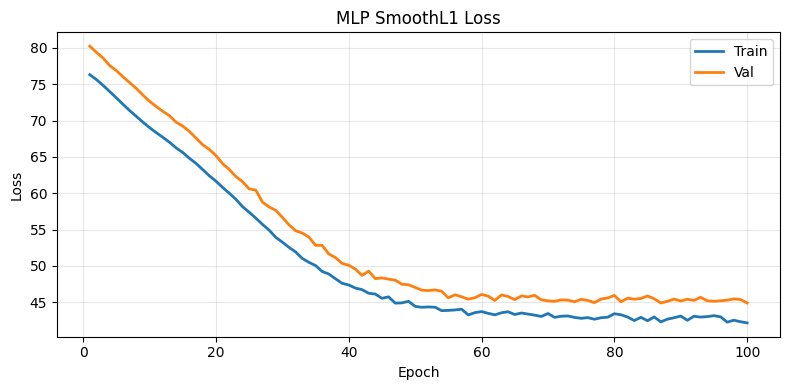

✓ Saved mlp_training_curves.png


In [11]:
# ── Training curves ───────────────────────────────────────────────────────────
ep = range(1, len(mlp_history['train']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(ep, mlp_history['train'], label='Train', lw=2)
plt.plot(ep, mlp_history['val'],   label='Val',   lw=2)
plt.title('MLP SmoothL1 Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=150)
plt.show()
print('✓ Saved mlp_training_curves.png')

In [12]:
# ── Step 7: Uncertainty estimation via MC Dropout ─────────────────────────────
#
# Run N forward passes with dropout ACTIVE → collect distribution of
# predictions → report mean ± std as uncertainty bounds.

MC_SAMPLES = 50

def mc_predict(model, x_tensor: torch.Tensor, n_samples: int = MC_SAMPLES):
    """
    Returns (mean, std) each of shape (batch, num_targets).
    Model must have dropout layers — keeps them active during inference.
    """
    model.train()   # keep dropout ON
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(model(x_tensor).cpu().numpy())
    preds = np.stack(preds, axis=0)   # (n_samples, batch, targets)
    return preds.mean(axis=0), preds.std(axis=0)


# ── Load best checkpoint ──────────────────────────────────────────────────────
# weights_only=False needed because checkpoint contains numpy arrays (feat_mean/std)
ckpt = torch.load(MLP_CKPT, map_location=device, weights_only=False)
mlp.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded MLP checkpoint (epoch {ckpt["epoch"]})')

# ── Run MC Dropout on test set ────────────────────────────────────────────────
X_te_t = torch.tensor(X_test_n, dtype=torch.float32).to(device)
mc_mean, mc_std = mc_predict(mlp, X_te_t, MC_SAMPLES)

# ── Metrics ───────────────────────────────────────────────────────────────────
mae_mlp  = np.mean(np.abs(mc_mean - y_test), axis=0)
rmse_mlp = np.sqrt(np.mean((mc_mean - y_test) ** 2, axis=0))
mape_mlp = np.mean(np.abs((mc_mean - y_test) /
                    np.clip(np.abs(y_test), 1e-6, None)), axis=0) * 100
unc_mean = mc_std.mean(axis=0)   # average uncertainty per target

print('\n' + '=' * 70)
print(f'MLP TEST RESULTS  (MC Dropout, {MC_SAMPLES} samples)  [{len(y_test)} dishes]')
print('=' * 70)
print(f'{"Target":<25} {"MAE":>8} {"RMSE":>8} {"MAPE%":>8} {"±Uncert":>10}')
print('-' * 70)
for i, col in enumerate(TARGET_COLS):
    print(f'{col:<25} {mae_mlp[i]:>8.2f} {rmse_mlp[i]:>8.2f} '
          f'{mape_mlp[i]:>8.1f} {unc_mean[i]:>10.2f}')
print('-' * 70)
print(f'{"Overall (mean)":<25} {mae_mlp.mean():>8.2f} {rmse_mlp.mean():>8.2f} '
      f'{mape_mlp.mean():>8.1f} {unc_mean.mean():>10.2f}')
print('=' * 70)


Loaded MLP checkpoint (epoch 100)

MLP TEST RESULTS  (MC Dropout, 50 samples)  [326 dishes]
Target                         MAE     RMSE    MAPE%    ±Uncert
----------------------------------------------------------------------
calories                    119.79   158.69    182.1      37.24
fat                           7.67    10.66 475729.4       1.85
protein                      11.01    15.75    308.5       2.65
carb                         11.14    14.35 13089942.0       2.78
----------------------------------------------------------------------
Overall (mean)               37.40    49.86 3391540.5      11.13


In [13]:
# ── Step 8: Compare Phase 3 (ResNet) vs Phase 4 (YOLO+Depth+MLP) ──────────────
#
# Load Phase 3 checkpoint if available and run on the SAME test split.

import torchvision.models as tv_models
import torchvision.transforms as T

P3_CKPT = 'best_model.pt'

class NutritionEstimator(nn.Module):
    def __init__(self, num_targets, backbone='resnet50'):
        super().__init__()
        base = tv_models.resnet50(weights=None)
        in_f = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base
        self.head = nn.Sequential(
            nn.Linear(in_f, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, num_targets),
        )
    def forward(self, x): return self.head(self.backbone(x))


if os.path.isfile(P3_CKPT):
    # weights_only=False needed for checkpoints saved with numpy/non-tensor metadata
    p3_ckpt = torch.load(P3_CKPT, map_location=device, weights_only=False)
    p3_cols  = p3_ckpt.get('target_cols', TARGET_COLS)
    p3_model = NutritionEstimator(num_targets=len(p3_cols)).to(device)
    p3_model.load_state_dict(p3_ckpt['model_state_dict'])
    p3_model.eval()

    val_tf = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    df_test_p3 = df_valid.iloc[te_idx].reset_index(drop=True)

    p3_preds, p3_tgts = [], []
    for _, row in df_test_p3.iterrows():
        did  = row[dish_id_col]
        dp   = os.path.join(img_dir, did)
        imgs = sorted([f for f in os.listdir(dp)
                       if f.lower().endswith(('.jpg','.png'))
                       and 'depth' not in f.lower()])
        if not imgs: continue
        img = Image.open(os.path.join(dp, imgs[0])).convert('RGB')
        with torch.no_grad():
            pred = p3_model(val_tf(img).unsqueeze(0).to(device)).squeeze().cpu().numpy()
        p3_preds.append(pred)
        p3_tgts.append(row[TARGET_COLS].values.astype(float))

    p3_preds = np.array(p3_preds)
    p3_tgts  = np.array(p3_tgts)
    mae_p3   = np.mean(np.abs(p3_preds - p3_tgts), axis=0)

    print('\n── Comparison: Phase 3 (ResNet-50) vs Phase 4 (YOLO+Depth+MLP) ──')
    print(f'{"Target":<25} {"P3 MAE":>10} {"P4 MAE":>10} {"Δ MAE":>10}')
    print('-' * 57)
    for i, col in enumerate(TARGET_COLS):
        delta = mae_mlp[i] - mae_p3[i]
        arrow = '↑ worse' if delta > 0 else '↓ better'
        print(f'{col:<25} {mae_p3[i]:>10.2f} {mae_mlp[i]:>10.2f} '
              f'{delta:>+10.2f}  {arrow}')
    print('-' * 57)
    print('(Phase 4 uses only geometric features — no pixel texture)')
else:
    print(f'⚠ {P3_CKPT} not found — skipping Phase 3 comparison.')
    print('  Place best_model.pt (from Kaggle output) here to compare.')



── Comparison: Phase 3 (ResNet-50) vs Phase 4 (YOLO+Depth+MLP) ──
Target                        P3 MAE     P4 MAE      Δ MAE
---------------------------------------------------------
calories                      194.25     119.79     -74.46  ↓ better
fat                            12.79       7.67      -5.13  ↓ better
protein                        19.37      11.01      -8.36  ↓ better
carb                           16.01      11.14      -4.87  ↓ better
---------------------------------------------------------
(Phase 4 uses only geometric features — no pixel texture)


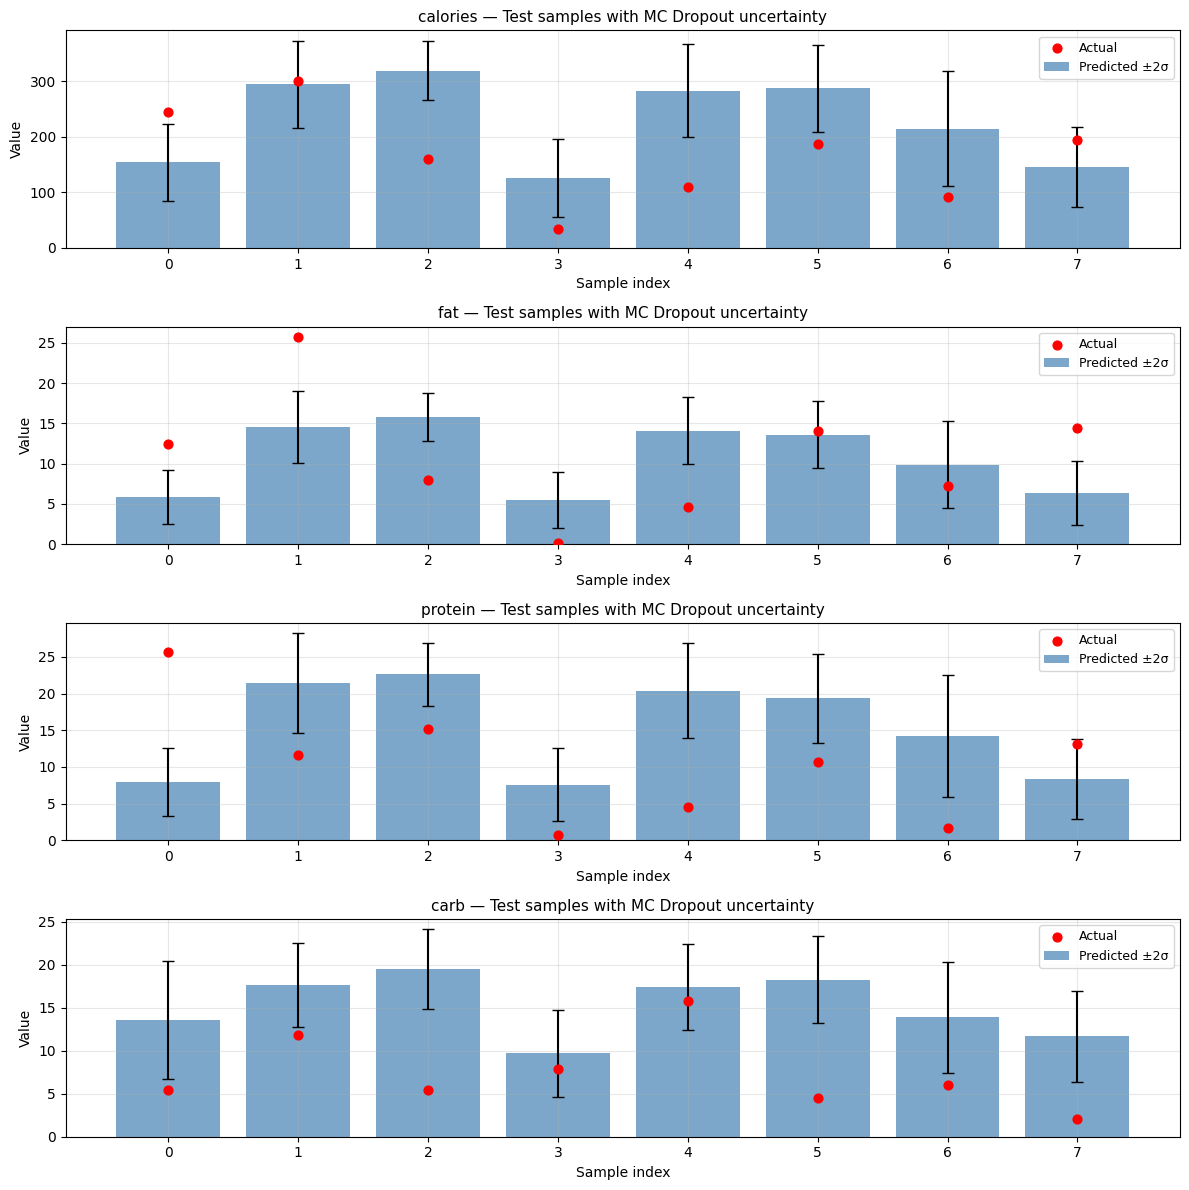

✓ Saved uncertainty_plot.png


In [14]:
# ── Visualise uncertainty on 8 test samples ───────────────────────────────────
n_show = min(8, len(y_test))
fig, axes = plt.subplots(NUM_TARGETS, 1, figsize=(12, 3 * NUM_TARGETS))
if NUM_TARGETS == 1: axes = [axes]

x_pos = np.arange(n_show)
for i, col in enumerate(TARGET_COLS):
    ax = axes[i]
    ax.bar(x_pos, mc_mean[:n_show, i], yerr=mc_std[:n_show, i] * 2,
           capsize=4, color='steelblue', alpha=0.7, label='Predicted ±2σ')
    ax.scatter(x_pos, y_test[:n_show, i], color='red', zorder=5,
               label='Actual', s=40)
    ax.set_title(f'{col} — Test samples with MC Dropout uncertainty', fontsize=11)
    ax.set_xlabel('Sample index'); ax.set_ylabel('Value')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('uncertainty_plot.png', dpi=150)
plt.show()
print('✓ Saved uncertainty_plot.png')

In [15]:
# ── Step 9: Save pipeline artifacts ───────────────────────────────────────────
# best_mlp.pt is already saved during training.
# We also save the feature normalisation stats so app.py can use them.

np.savez('mlp_feat_stats.npz',
         feat_mean=feat_mean,
         feat_std=feat_std,
         target_cols=np.array(TARGET_COLS))
print('✓ Saved mlp_feat_stats.npz')
print('  Artifacts to download from Kaggle output:')
print('    best_mlp.pt          → models/')
print('    mlp_feat_stats.npz   → models/')
print('    features_cache.npz   → (optional, for reuse)')

✓ Saved mlp_feat_stats.npz
  Artifacts to download from Kaggle output:
    best_mlp.pt          → models/
    mlp_feat_stats.npz   → models/
    features_cache.npz   → (optional, for reuse)


In [16]:
# ── Step 10: Phase 4 Summary ──────────────────────────────────────────────────
print('=' * 65)
print('PHASE 4 SUMMARY')
print('=' * 65)
print(f'  Pipeline       : YOLOv8-seg → Depth map → MLP regression')
print(f'  Features       : {FEAT_SIZE} geometric (mask area + depth stats)')
print(f'  Depth source   : RealSense depth images (MiDaS fallback)')
print(f'  MLP params     : {total:,}')
print(f'  Uncertainty    : MC Dropout ({MC_SAMPLES} samples)')
print(f'  Targets        : {TARGET_COLS}')
print()
print(f'  Test-set results (Phase 4 MLP):')
for i, col in enumerate(TARGET_COLS):
    print(f'    {col:<25} MAE={mae_mlp[i]:.2f}  RMSE={rmse_mlp[i]:.2f}  '
          f'MAPE={mape_mlp[i]:.1f}%  ±{unc_mean[i]:.2f}')
print()
print(f'  Checkpoints    : {MLP_CKPT}, mlp_feat_stats.npz')
print('=' * 65)
print('✓ Phase 4 complete — update app.py to use the new pipeline')

PHASE 4 SUMMARY
  Pipeline       : YOLOv8-seg → Depth map → MLP regression
  Features       : 9 geometric (mask area + depth stats)
  Depth source   : RealSense depth images (MiDaS fallback)
  MLP params     : 12,196
  Uncertainty    : MC Dropout (50 samples)
  Targets        : ['calories', 'fat', 'protein', 'carb']

  Test-set results (Phase 4 MLP):
    calories                  MAE=119.79  RMSE=158.69  MAPE=182.1%  ±37.24
    fat                       MAE=7.67  RMSE=10.66  MAPE=475729.4%  ±1.85
    protein                   MAE=11.01  RMSE=15.75  MAPE=308.5%  ±2.65
    carb                      MAE=11.14  RMSE=14.35  MAPE=13089942.0%  ±2.78

  Checkpoints    : best_mlp.pt, mlp_feat_stats.npz
✓ Phase 4 complete — update app.py to use the new pipeline
